# Chapter 4 - Nondeterministic Finite Automata

## Learning Objectives

After completing this chapter, you will be able to:

* Define a nondeterministic finite automaton (NFA).
* Explain the difference between a deterministic finite automaton (DFA) and an NFA.
* Represent an NFA with a state diagram.
* Define a language with an NFA.
* Understand the equivalence of DFAs and NFAs.

We use these libraries to build and visualize the directed graphs we'll be using in this chapter:

| Package | Purpose |
|---|---|
| `io` | Basic library for handling input and output |
| `base64` | Manages special characters |
| `IPython` | Provides additional Python functionality |
| `graphviz` | General graph visualization |

The cell below checks whether each package is already installed and installs
it automatically if not. This is safe to re-run; it only installs what is
missing.

**Outside Jupyter**, install once from the terminal:
```bash
pip install io base64 IPython graphviz
```

In [1]:
# Install required Python packages using pip
import sys
import importlib.util
import subprocess

def install_if_missing(package):
    if importlib.util.find_spec(package) is None:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"{package} has been installed")
    else:
        print(f"{package} is already installed")

required_packages = ['io', 'base64', 'IPython', 'graphviz']
for package in required_packages:
    install_if_missing(package)

import io
import base64
from IPython.display import display, HTML
from graphviz import Digraph, Source

io is already installed
base64 is already installed
IPython is already installed
graphviz is already installed


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Display Graph with Caption
#
# Running outside Jupyter:
#   python display_graph_with_caption.py
# ─────────────────────────────────────────────────────────────────────────────

def display_graph_with_caption(graph: Digraph, fig_num: str, title: str, alt_text: str, format: str = 'png'):
    """
    Takes a graphviz.Digraph object and displays it in a Jupyter Notebook cell
    as an accessible HTML image with a structured figure caption.

    Parameters:
    - graph (Digraph): The graphviz Digraph object to display.
    - fig_num (str): The figure number (e.g., "1", "3.1a") which is formatted as "Figure X". (UPDATED TO STRING)
    - title (str): The descriptive title for the figure caption.
    - alt_text (str): The full accessible description for screen readers.
    - format (str): The image format ('png' or 'svg' recommended). Defaults to 'png'.
    """
    if not isinstance(graph, Digraph):
        raise TypeError("The 'graph' parameter must be a graphviz.Digraph object.")

    # 1. Format Figure Number and Caption
    # fig_num is now used directly as a string
    figure_number_str = f"Figure {fig_num}"
    full_caption = f"<b>{figure_number_str}:</b> {title}"

    # 2. Get the raw binary image data using pipe()
    try:
        img_binary_data = graph.pipe(format=format)
    except Exception as e:
        print(f"Error generating graph image using pipe(): {e}")
        return

    # 3. Encode the binary data to Base64
    img_data = base64.b64encode(img_binary_data).decode('utf-8')

    # 4. Determine the mime type for the HTML
    mime_type = f"image/{format}"

    # 5. Construct the full accessible HTML block
    html_output = f"""
    <figure style="text-align: center; margin: 1em 0;">
        <img src="data:{mime_type};base64,{img_data}" alt="{alt_text}"
             style="max-width: 100%; height: auto; display: block; margin: 0 auto;" />
        <figcaption style="margin-top: 0.5em; font-size: 0.9em; color: #333;">
            {full_caption}
        </figcaption>
    </figure>
    """

    # 6. Display the HTML in the notebook
    display(HTML(html_output))

## Section 4.1 - The Idea of Nondeterminism

For the finite automata we've seen so far, if you're at any state in the automaton then every letter in the input alphabet $\Sigma$ has a single corresponding transition. This means that at any state there is one and only one place to go for a given input, and consequently for any sequence of inputs there's only one corresponding path in the finite automaton. There are no options, and there is no ambiguity. Everything is determined. We call finite automata like this *deterministic* finite automata (DFAs)- for any input string, the path and final state in the finite automaton is *uniquely determined*.

We're now going to modify this, and introduce an element of choice. This means that for any given input string, there might be multiple corresponding paths through the finite automaton, depending on the choices that are made. We will call these finite automata *nondeterministic finite automata* (NFAs), and they are the focus of this chapter.

As an example, take a look at the state diagram below.

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# State diagram of a nondeterministic finite automaton (NFA).
#
# ─────────────────────────────────────────────────────────────────────────────

NFA_example = Digraph()
NFA_example.attr(rankdir='LR') # This specifies the diagram should go left to right

# Start arrow
NFA_example.node('', shape='none')
NFA_example.edge('', 'q0')

# States
NFA_example.node('q0', shape='circle') # Initial state
NFA_example.node('q1', shape='circle')
NFA_example.node('q2', shape='circle')
NFA_example.node('q3', shape='doublecircle') # Accept state

# Transitions
NFA_example.edge('q0', 'q0', label='b')
NFA_example.edge('q0', 'q1', label='a,b')
NFA_example.edge('q1', 'q2', label='b')
NFA_example.edge('q2', 'q0', label='a')
NFA_example.edge('q2', 'q3', label='<&lambda;>')
NFA_example.edge('q3', 'q3', label='a,b')


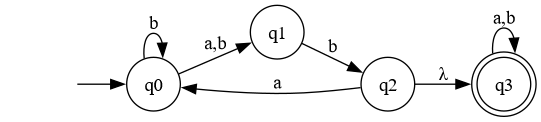

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Display of the diagram for a nondeterministic finite automaton (NFA).
#
# ─────────────────────────────────────────────────────────────────────────────

fig_num_1 = "1"
title_1 = "Nondeterministic Finite Automaton Example"
alt_text_1=(
        "A nondeterministic finite automaton (NFA) with four states: q0, q1, q2, and q3. "
        "State q0 is the initial state, and State q3 is the single accept state (double circle). "
        "The transitions demonstrate non-deterministic behavior: "
        "From q0, input 'b' transitions to both q0 and q1. Input 'a' transitions to q1 only. "
        "From q1, 'b' goes to state q2. "
        "From q2, 'a' goes back to q0 and an epsilon transition (lambda, denoted by <&lambda;>) goes to the accept state q3. "
        "The accept state q3 self-loops on both 'a' and 'b'."
    )

display_graph_with_caption(NFA_example, fig_num_1, title_1, alt_text_1)

Notice a few things we haven't seen before:

* At our initial state $q_{0}$, there are *two* transitions corresponding with the input $b$.
* At the state $q_{1}$ there is no transition for the input $a$.
* At the state $q_{2}$ there is a transition for the empty input $\lambda$.

What do these changes mean? They mean:

* At state $q_{0}$, if the input is $b$, then there are two possible transitions, either stay at $q_{0}$ or move to $q_{1}$, and a choice must be made as to which one is taken.
* At state $q_{1}$ if the input is an $a$ then there is no path to follow, and in this situation our path terminates or "crashes".
* At state $q_{2}$ a choice can be made to transition to $q_{3}$ without even reading an input. However, this choice isn't forced, and staying at $q_{2}$ is also an option.

These changes mean that for a given sequence of input characters there might be multiple possibilities for the state of the NFA, or there might be none. For example:

* The input sequence $aba$ has two possible states final states, $q_{0}$ or $q_{3}$, depending on whether the $\lambda$-transition is made at $q_{2}$.

* The input sequence $aab$ has no possible final state, because after reading the first $a$ the automaton must transition from $q_{0}$ to $q_{1}$, and then after reading the second $a$ there is no corresponding transition and the path terminates.

* The input sequence $abb$ has only one possible final state, corresponding to transitioning from $q_{0}$ to $q_{1}$ after the $a$ is read, transitioning from $q_{1}$ to $q_{2}$ after the first $b$ is read, transitioning from $q_{2}$ to $q_{3}$ with the $\lambda$-transition, and then transitioning from $q_{3}$ to $q_{3}$ (staying put) when the final $b$ is read. If the transition from $q_{2}$ to $q_{3}$ with the $\lambda$-transition is not chosen, then the second $b$ has no corresponding transition and the path terminates.

We say that an NFA accepts a given input string if *any* of the possible final states are accepting states. So, it would accept both $aba$ and $abb$, even though one of the possible final states for the sequence $aba$ isn't an accepting state.

## Section 4.2 - DFAs vs. NFAs

The table below summarizes the important differences between DFAs and NFAs.

| DFAs | NFAs |
| --- | --- |
| One unique starting state. | At least one starting state, but possibly more. |
| Every state has exactly one transition for every character in the input alphabet ($\Sigma$). | States can have multiple transition for a character in $\Sigma$, or none at all. |
| At any step in the reading of the input string, the DFA is in one unique state. | At any step in the reading of the input string, the NFA can be in multiple states, or none at all. |
| A DFA accepts an input string if after reading the string it's in an accepting state. | A NFA accepts an input string if after reading the string it could possibly be in an accepting state. |

The NFA is much more flexible than the DFA, and you might think this would mean there are languages that can be recognized by an NFA that cannot be recognized by a DFA. However, we'll see this is not the case.

## Section 4.3 - Formal Definition of an NFA

Formally, a nondeterministic finite automaton is a 5-tuple $(Q,\Sigma,\delta,S,F)$ where:

1.   $Q$ is a *finite* set of states,
2.   $\Sigma$ is a finite alphabet,
3.   $\delta : Q \times \Sigma_{\lambda} \rightarrow P(Q)$ is the transition function,
4.   $S \subseteq Q$ is the (non-empty) subset of initial (start) states, and
5.   $F \subseteq Q$ is the set of accepting states.

Here $\Sigma_{\lambda}$ means the finite alphabet $\Sigma$ plus the empty string, represented by the symbol $\lambda$. So, if $\Sigma = \{a,b\}$, then $\Sigma_{\lambda} = \{a,b,\lambda\}$. The term $P(Q)$ is the *powerset* of $Q$, and represents the set of all possible subsets of $Q$. We need the powerset because a given state and input combination can have more than one resulting state. For example, in the NFA from Section 4.1 above, the transition function for $q_{0}$ and the input $b$ would be $\delta(q_{0},b) \rightarrow \{q_{0},q_{1}\}$, because in $q_{0}$ with the input $b$ the NFA can either stay at $q_{0}$ or transition to $q_{1}$.

## Section 4.4 - Representing Nondeterministic Finite Automata in Python

We're going to modify the FA class we created in Section 3.3. First, we'll define how the class is constructed, provide a validation method to ensure the arguments (the 5-tuple) properly define an NFA, and provide methods for constructing and displaying the NFA's state diagram. These are all similar to the FA class.

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Create the nondeterministic finite automaton (NFA) class.
#
# Unlike in the previous chapter, here we include some of its basic methods.
#
# Running outside Jupyter:
#   python NFA.py
# ─────────────────────────────────────────────────────────────────────────────

class NFA:
    def __init__(self, states, alphabet, transition_function, start_states, accept_states):
        self.states = set(states)
        self.alphabet = set(alphabet)
        # Transition function format: (state, symbol) -> {next_states}
        self.transition_function = transition_function
        self.start_states = set(start_states)
        self.accept_states = set(accept_states)

        self._validate()

    def _validate(self):
        """Ensures the NFA structure is valid."""
        if not self.start_states.issubset(self.states):
            raise ValueError("Start states must be a subset of states.")
        if not self.accept_states.issubset(self.states):
            raise ValueError("Accept states must be a subset of states.")

        # Ensure all transitions are to valid states and symbols
        for (state, symbol), next_states in self.transition_function.items():
            if state not in self.states:
                raise ValueError(f"Invalid transition: ({state}, {symbol}) - source state not in states.")

            # Allow epsilon (lambda) transition symbol
            if symbol not in self.alphabet and symbol != '<&lambda;>':
                raise ValueError(f"Symbol '{symbol}' not in alphabet or is not lambda.")

            # Check if the destination is a set of states and if all states in the set are valid
            if not isinstance(next_states, set) or not next_states.issubset(self.states):
                raise ValueError(f"Invalid transition: ({state}, {symbol}) → {next_states} - destination is not a set of states or contains invalid states.")


    def _build_graph(self):
        """Generates the graphviz Digraph object using standard settings."""
        dot = Digraph() # Reverted to standard Digraph
        dot.attr(rankdir='LR')
        dot.node('', shape='none')

        # Handle multiple start states with empty edge
        for start_state in self.start_states:
            dot.edge('', str(start_state))

        for state in self.states:
            shape = 'doublecircle' if state in self.accept_states else 'circle'
            dot.node(str(state), label=str(state), shape=shape)

        # Group transitions by (src, dst) to show multiple labels on one edge
        transition_groups = {}
        for (src, symbol), dst_set in self.transition_function.items():
            for dst in dst_set:
                key = (src, dst)
                if key not in transition_groups:
                    transition_groups[key] = []
                transition_groups[key].append(symbol)

        for (src, dst), symbols in transition_groups.items():
            label = ",".join(sorted(symbols))
            dot.edge(str(src), str(dst), label=label)

        return dot

    def show(self, fig_num=None, title=None, alt_text="Nondeterministic finite automaton diagram.", format='png'):
        """
        Generates and displays the NFA digraph as an accessible HTML image.

        Parameters:
        - fig_num (str): Figure number (e.g., "Figure 3.2").
        - title (str): Title of the figure (e.g., "NFA accepting binary strings").
        - alt_text (str): Accessible description for screen readers.
        - format (str): Output format for graphviz ('png' or 'svg' recommended).
        """
        graph = self._build_graph()

        # Get the raw image data using pipe()
        img_binary_data = graph.pipe(format=format)
        img_data = base64.b64encode(img_binary_data).decode('utf-8')

        # Construct the caption
        caption_content = ""
        if fig_num or title:
            caption_parts = []
            if fig_num:
                caption_parts.append(f"<b>Figure {fig_num}:</b>")
            if title:
                caption_parts.append(title)

            caption_content = " ".join(caption_parts)

        # Determine the mime type for the HTML
        mime_type = f"image/{format}"

        # Construct the full HTML block
        html_output = f"""
        <figure style="text-align: center; margin: 1em 0;">
            <img src="data:{mime_type};base64,{img_data}" alt="{alt_text}"
                 style="max-width: 100%; height: auto; display: block; margin: 0 auto;" />

            {f'<figcaption style="margin-top: 0.5em; font-size: 0.9em; color: #333;">{caption_content}</figcaption>' if caption_content else ''}
        </figure>
        """

        # Display the HTML in the notebook
        display(HTML(html_output))

We can use this to create and then display the state diagram for the example NFA from Section 4.1:

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Create the NFA from Section 4.1 using our NFA class.
#
# ─────────────────────────────────────────────────────────────────────────────

NFA_example_4_1 = NFA(
    states={'q0', 'q1', 'q2', 'q3'},
    alphabet={'a', 'b'},
    transition_function={
        ('q0', 'b'): {'q0', 'q1'},
        ('q0', 'a'): {'q1'},
        ('q1', 'b'): {'q2'},
        ('q2', 'a'): {'q0'},
        ('q2', '<&lambda;>'): {'q3'},
        ('q3', 'a'): {'q3'},
        ('q3', 'b'): {'q3'},
    },
    start_states={'q0'},
    accept_states={'q3'}
)


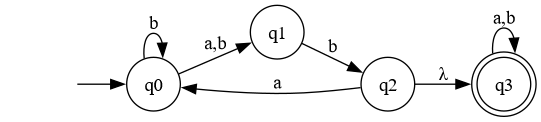

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Display the state diagram of the NFA from Section 4.1 using our NFA class.
#
# ─────────────────────────────────────────────────────────────────────────────

fig_num_2 = "2"
title_2 = "Example NFA built with NFA class"
alt_text_2 = (
    "A nondeterministic finite automaton (NFA) with four states: q0, q1, q2, and q3. "
    "State q0 is the initial state, and State q3 is the single accept state (double circle). "
    "The transitions demonstrate non-deterministic behavior: "
    "From q0, input 'b' transitions to both q0 and q1. Input 'a' transitions to q1 only. "
    "From q1, 'b' goes to state q2. "
    "From q2, 'a' goes back to q0 and an epsilon transition (lambda, denoted by <&lambda;>) goes to the accept state q3. "
    "The accept state q3 self-loops on both 'a' and 'b'."
)

NFA_example_4_1.show(fig_num=fig_num_2, title=title_2, alt_text=alt_text_2)

As with the DFA, we can construct a method for tracing the sequence of states of the automaton as it processes an input string. However, unlike with the DFA, for an NFA this won't be a sequence of states but a sequence of sets of states.

First, we'll want to create a function that takes a set of states and a transition function, and determines all the states that can be reached from this set just through $\lambda$-transitions.

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Function for finding all the states that can be reached from a set of states 
# through lambda-transitions
#
# ─────────────────────────────────────────────────────────────────────────────

def lambda_closure(states, transition_function):
  lambda_states = states.copy()
  for state in states:
    if (state, '<&lambda;>') in transition_function:
      lambda_states.update(transition_function[(state, '<&lambda;>')])
  if lambda_states != states:
    lambda_states.update(lambda_closure(lambda_states, transition_function)) #Note the use of recursion
  return lambda_states

Now, we'll create a method for tracing through the sequence of states of an NFA as it processes an input string.

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Method for tracing through the sequence of states of the nondeterministic
# finite automaton as it processes an input string.
#
# ─────────────────────────────────────────────────────────────────────────────

def trace(self, input_string):
  current_states = lambda_closure(self.start_states, self.transition_function)
  trace = [current_states]
  for symbol in input_string:
    next_states = set()
    for state in current_states:
      if (state, symbol) in self.transition_function:
        next_states.update(self.transition_function[(state, symbol)])
    current_states = lambda_closure(next_states, self.transition_function)
    trace.append(current_states)
  return trace

# Add the function as a method of the NFA class.
NFA.trace = trace

Let's check how this method handles the three example inputs from the end of Section 4.1:

In [10]:
NFA_example_4_1.trace('aba')

[{'q0'}, {'q1'}, {'q2', 'q3'}, {'q0', 'q3'}]

In [11]:
NFA_example_4_1.trace('aab')

[{'q0'}, {'q1'}, set(), set()]

*Note* - Here *set()* means the empty set $\emptyset$.

In [12]:
NFA_example_4_1.trace('abb')

[{'q0'}, {'q1'}, {'q2', 'q3'}, {'q3'}]

Finally, we can use this *trace* method to construct a method that determines whether an NFA accepts a given input string.

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Method for determining if an NFA accepts a given input string.
#
# ─────────────────────────────────────────────────────────────────────────────

def accepts(self, input_string):
  trace = self.trace(input_string)
  return any(state in self.accept_states for state in trace[-1])

# Add the function as a method of the NFA class.
NFA.accepts = accepts

Checking this on the NFA from Section 4.1 and the three example inputs:

In [14]:
NFA_example_4_1.accepts('aba')

True

In [15]:
NFA_example_4_1.accepts('aab')

False

In [16]:
NFA_example_4_1.accepts('abb')

True

## Section 4.5 - Equivalence of NFAs and DFAs

We say that an NFA and a DFA are *equivalent* if they recognize the same language.

DFAs are a special case of NFAs, and so any DFA is also an NFA. This means that, obviously, for any DFA there is an equivalent NFA (the DFA itself).

It might be a bit surprising that the other direction is also true. Namely, for any NFA, there is an equivalent DFA.

While proving this isn't particularly difficult, it will be the most in-depth proof we've seen so far. So, before we present the general proof, we'll illustrate the idea with an example.

### Subsection 4.5.1 - Constructing an Equivalent DFA from an NFA

Suppose you have the NFA below.

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# NFA accepting any string with "a" as its second-to-last letter.
#
# ─────────────────────────────────────────────────────────────────────────────

NFA_a_2nd_to_last = NFA(
    states={'q0', 'q1', 'q2'},
    alphabet={'a', 'b'},
    transition_function={
        ('q0', 'a'): {'q0', 'q1'},
        ('q0', 'b'): {'q0'},
        ('q1', 'a'): {'q2'},
        ('q1', 'b'): {'q2'},
    },
    start_states={'q0'},
    accept_states={'q2'}
)


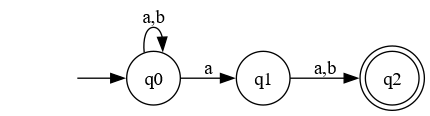

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# Display of an NFA accepting any string with "a" as its second-to-last letter.
#
# ─────────────────────────────────────────────────────────────────────────────

fig_num_3 = "3"
title_3 = "NFA recognizing all strings with 'a' as the next-to-last letter"
alt_text_3 = (
    "A nondeterministic finite automaton (NFA) with three states: q0, q1, and q2. "
    "State q0 is the initial state. State q2 is the single accept state (double circle). "
    "The machine recognizes strings where the second-to-last symbol is 'a'. "
    "From q0: The machine non-deterministically transitions to q0 or q1 on 'a', but only self-loops to q0 on 'b'. This keeps track of arbitrary input. "
    "State q1 represents the state where the previous symbol was 'a'. "
    "From q1: The machine transitions to the accept state q2 on both 'a' and 'b'. "
    "State q2 accepts the string, indicating that 'a' was the second-to-last symbol."
)

NFA_a_2nd_to_last.show(fig_num=fig_num_3, title=title_3, alt_text=alt_text_3)

This NFA recognizes the language of all strings over the alphabet $\Sigma = \{a,b\}$ for which $a$ is the next-to-last letter.

If we gave this NFA the input string $aba$ then, depending on the choices made, there are two possible states, $q_{0}$ or $q_{1}$, the NFA could be in.

In [19]:
NFA_a_2nd_to_last.trace('aba')

[{'q0'}, {'q0', 'q1'}, {'q0', 'q2'}, {'q0', 'q1'}]

If we gave this NFA the input string $aab$ then, again depending on the choices made, there are two possible states, $q_{0}$ or $q_{2}$, the NFA could be in.

In [20]:
NFA_a_2nd_to_last.trace('aab')

[{'q0'}, {'q0', 'q1'}, {'q0', 'q1', 'q2'}, {'q0', 'q2'}]

As neither $q_{0}$ not $q_{1}$ are accepting states, the string $aba$ would not be accepted by the NFA.

In [21]:
NFA_a_2nd_to_last.accepts('aba')

False

Because $q_{2}$ is an accepting state the string $aab$ would be.

In [22]:
NFA_a_2nd_to_last.accepts('aab')

True

We'd like to find a DFA that accepts the same language as this NFA, and to do so the basic idea is the states of this DFA represent all the different possible subsets of states from the NFA. There are three states in this NFA, and so its set of states is $Q = \{q_{0}, q_{1}, q_{2}\}$. The set of possible subsets of $Q$, its *powerset*, is: $P(Q) = \{\emptyset, \{q_{0}\}, \{q_{1}\}, \{q_{2}\}, \{q_{0}, q_{1}\}, \{q_{0}, q_{2}\}, \{q_{1}, q_{2}\}, \{q_{0}, q_{1}, q_{2}\}\}$. Each of these subsets is a state within our DFA, which we represent below.

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# DFA whose states are the powersets of the NFA above.
#
# ─────────────────────────────────────────────────────────────────────────────

DFA_states = Digraph()
DFA_states.attr(rankdir='LR') # This specifies the diagram should go left to right

# States
DFA_states.node('empty', label='\u00D8', shape='circle')
DFA_states.node('{q0}', shape='circle')
DFA_states.node('{q1}', shape='circle')
DFA_states.node('{q2}', shape='circle')
DFA_states.node('{q0,q1}', shape='circle')
DFA_states.node('{q0,q2}', shape='circle')
DFA_states.node('{q1,q2}', shape='circle')
DFA_states.node('{q0,q1,q2}', shape='circle')


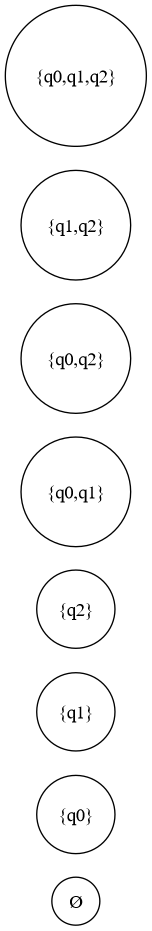

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# Display of the powerset states.
#
# ─────────────────────────────────────────────────────────────────────────────

fig_num_4 = "4"
title_4 = "DFA States (Power Set Construction)"
alt_text_4 = (
    "A state diagram showing the eight possible states generated by the power set construction (subset construction) "
    "from an NFA with three states: q0, q1, and q2. The nodes are labeled as the empty set (Ø) and all seven non-empty "
    "subsets of {q0, q1, q2}: {q0}, {q1}, {q2}, {q0, q1}, {q0, q2}, {q1, q2}, and the full set {q0, q1, q2}. No transitions are shown."
)

display_graph_with_caption(DFA_states, fig_num_4, title_4, alt_text_4)

Now, suppose we're in the state $\{q_{0},q_{1}\}$ and we read the input $b$. What is the corresponding transition? Well, it's the possible states we could transition to in the NFA from either of those states. In the NFA if we're in state $q_{0}$ and we read $b$, then we must stay at $q_{0}$. If we're in state $q_{1}$ and we read $b$ then we must transition to $q_{2}$. So, in the DFA if we're in state $\{q_{0},q_{1}\}$ and we read a $b$ we transition to the state $\{q_{0},q_{2}\}$. What if we're in state $\{q_{0},q_{1}\}$ and we read the input $a$? Well, in the NFA if we're in state $q_{0}$ and we read $a$, then we either stay at $q_{0}$ or transition to $q_{1}$. In the NFA if we're in state $q_{1}$ and we read $a$, then we transition to $q_{2}$. So, in the DFA if we're in state $\{q_{0},q_{1}\}$ and we read $a$ we transition to the state $\{q_{0},q_{1},q_{2}\}$. The transitions for all the states and possible inputs are represented below.

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# Transitions for DFA accepting any string with "a" as its second-to-last 
# letter.
#
# ─────────────────────────────────────────────────────────────────────────────

DFA_states_and_edges = Digraph()
DFA_states_and_edges.attr(rankdir='LR') # This specifies the diagram should go left to right

# States
DFA_states.node('empty', label='\u00D8', shape='circle')
DFA_states_and_edges.node('{q0}', shape='circle')
DFA_states_and_edges.node('{q1}', shape='circle')
DFA_states_and_edges.node('{q2}', shape='circle')
DFA_states_and_edges.node('{q0,q1}', shape='circle')
DFA_states_and_edges.node('{q0,q2}', shape='circle')
DFA_states_and_edges.node('{q1,q2}', shape='circle')
DFA_states_and_edges.node('{q0,q1,q2}', shape='circle')

# Transitions
DFA_states_and_edges.edge('\u00D8', '\u00D8', label='a')
DFA_states_and_edges.edge('\u00D8', '\u00D8', label='b')
DFA_states_and_edges.edge('{q0}', '{q0,q1}', label='a')
DFA_states_and_edges.edge('{q0}', '{q0}', label='b')
DFA_states_and_edges.edge('{q1}', '{q2}', label='a')
DFA_states_and_edges.edge('{q1}', '{q2}', label='b')
DFA_states_and_edges.edge('{q2}', '\u00D8', label='a')
DFA_states_and_edges.edge('{q2}', '\u00D8', label='b')
DFA_states_and_edges.edge('{q0,q1}', '{q0,q1,q2}', label='a')
DFA_states_and_edges.edge('{q0,q1}', '{q0,q2}', label='b')
DFA_states_and_edges.edge('{q0,q2}', '{q0,q1}', label='a')
DFA_states_and_edges.edge('{q0,q2}', '{q0}', label='b')
DFA_states_and_edges.edge('{q1,q2}', '{q2}', label='a')
DFA_states_and_edges.edge('{q1,q2}', '{q2}', label='b')
DFA_states_and_edges.edge('{q0,q1,q2}', '{q0,q1,q2}', label='a')
DFA_states_and_edges.edge('{q0,q1,q2}', '{q0,q2}', label='b')


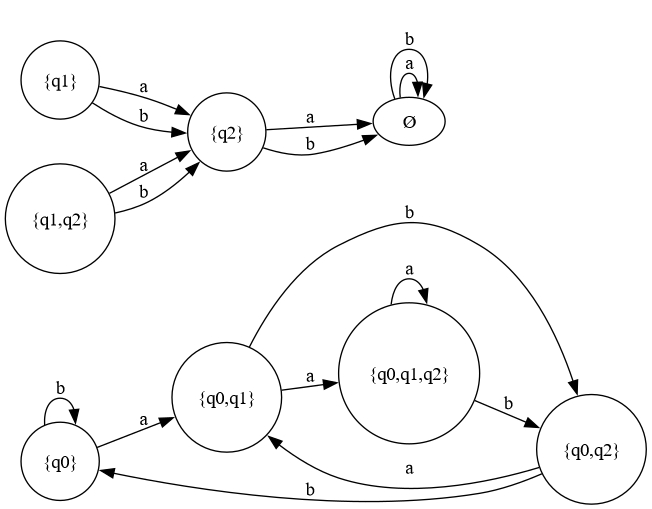

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# State diagram for DFA accepting any string with "a" as its second-to-last 
# letter.
#
# ─────────────────────────────────────────────────────────────────────────────

fig_num_5 = "5"
title_5 = "NFA to DFA State Diagram Showing All Transitions"
alt_text_5 = (
    "A Deterministic Finite Automaton (DFA) derived from subset construction on a three-state NFA, "
    "operating over the alphabet {a, b}. The DFA has eight states, labeled as all subsets of {q0, q1, q2}, "
    "including the empty set (Ø). "
    "The empty set state (Ø) is a trap state, looping back to itself on 'a' and 'b'. "
    "All 16 transitions required for a total DFA are shown connecting the subset states, "
    "demonstrating the deterministic mapping from each subset state on input 'a' and 'b'."
)

display_graph_with_caption(DFA_states_and_edges, fig_num_5, title_5, alt_text_5)


Now, what are the initial and accepting states of the DFA? Well, the initial state of the DFA is the one corresponding with the initial states of the NFA. In this case that's $\{q_{0}\}$. The accepting states are those that contain at least one accepting state of the NFA. As the only accepting state in the NFA is $q_{2}$, the accepting states of the DFA are $\{q_{2}\}, \{q_{0}, q_{2}\}, \{q_{1}, q_{2}\}$, and $\{q_{0}, q_{1}, q_{2}\}$. These are indicated in the state diagram below.

In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# DFA accepting any string with "a" as its second-to-last letter with initial
# and accepting states indicated.
#
# ─────────────────────────────────────────────────────────────────────────────

DFA_full = Digraph()
DFA_full.attr(rankdir='LR') # This specifies the diagram should go left to right

# Start arrow
DFA_full.node('', shape='none')
DFA_full.edge('', '{q0}')

# States
DFA_states.node('empty', label='\u00D8', shape='circle')
DFA_full.node('{q0}', shape='circle')
DFA_full.node('{q1}', shape='circle')
DFA_full.node('{q2}', shape='doublecircle')
DFA_full.node('{q0,q1}', shape='circle')
DFA_full.node('{q0,q2}', shape='doublecircle')
DFA_full.node('{q1,q2}', shape='doublecircle')
DFA_full.node('{q0,q1,q2}', shape='doublecircle')

# Transitions
DFA_full.edge('\u00D8', '\u00D8', label='a')
DFA_full.edge('\u00D8', '\u00D8', label='b')
DFA_full.edge('{q0}', '{q0,q1}', label='a')
DFA_full.edge('{q0}', '{q0}', label='b')
DFA_full.edge('{q1}', '{q2}', label='a')
DFA_full.edge('{q1}', '{q2}', label='b')
DFA_full.edge('{q2}', '\u00D8', label='a')
DFA_full.edge('{q2}', '\u00D8', label='b')
DFA_full.edge('{q0,q1}', '{q0,q1,q2}', label='a')
DFA_full.edge('{q0,q1}', '{q0,q2}', label='b')
DFA_full.edge('{q0,q2}', '{q0,q1}', label='a')
DFA_full.edge('{q0,q2}', '{q0}', label='b')
DFA_full.edge('{q1,q2}', '{q2}', label='a')
DFA_full.edge('{q1,q2}', '{q2}', label='b')
DFA_full.edge('{q0,q1,q2}', '{q0,q1,q2}', label='a')
DFA_full.edge('{q0,q1,q2}', '{q0,q2}', label='b')


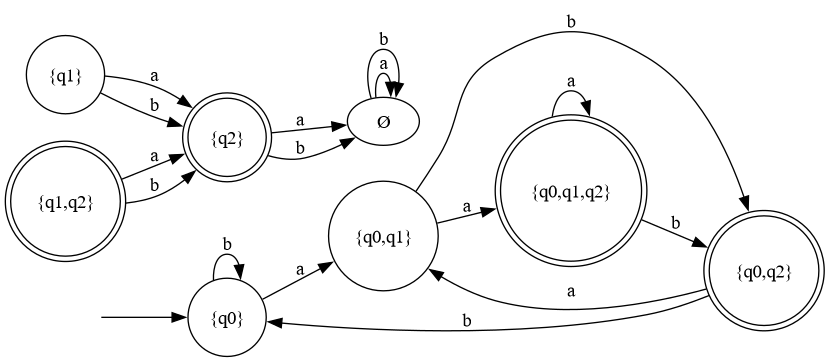

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# State diagram of DFA accepting any string with "a" as its second-to-last 
# letter with initial and accepting states indicated.
#
# ─────────────────────────────────────────────────────────────────────────────

fig_num_6 = "6"
title_6 = "NFA to DFA State Diagram with Initial and Accepting States"
alt_text_6 = (
    "A complete Deterministic Finite Automaton (DFA) derived from subset construction on a three-state NFA, "
    "operating over the alphabet {a, b}. The DFA has eight states derived from the subsets of {q0, q1, q2}. "
    "The initial state is {q0}. "
    "The accept states (double circles) are: {q2}, {q0, q2}, {q1, q2}, and {q0, q1, q2}. "
    "The empty set (Ø) is a non-accepting trap state, looping on 'a' and 'b'. "
    "The transitions connect the states based on input 'a' or 'b', ensuring every state has exactly two outgoing transitions. "
    "For example, the full state {q0, q1, q2} self-loops on 'a' and transitions to the accepting state {q0, q2} on 'b'."
)

display_graph_with_caption(DFA_full, fig_num_6, title_6, alt_text_6)

At this point we could be done. However, we can note that there are some states and transitions that cannot possibly be reached from the initial state, and so will never actually be involved in the operation of the DFA. Removing them gives us the DFA below.

In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# Cleaned up DFA accepting any string with "a" as its second-to-last letter.
#
# ─────────────────────────────────────────────────────────────────────────────

DFA_reduced = Digraph()
DFA_reduced.attr(rankdir='LR')  # Diagram direction: left to right

# Start arrow
DFA_reduced.node('', shape='none')
DFA_reduced.edge('', '{q0}')

# Reachable States
DFA_reduced.node('{q0}', shape='circle')
DFA_reduced.node('{q0,q1}', shape='circle')
DFA_reduced.node('{q0,q2}', shape='doublecircle')
DFA_reduced.node('{q0,q1,q2}', shape='doublecircle')

# Reachable Transitions
DFA_reduced.edge('{q0}', '{q0,q1}', label='a')
DFA_reduced.edge('{q0}', '{q0}', label='b')
DFA_reduced.edge('{q0,q1}', '{q0,q1,q2}', label='a')
DFA_reduced.edge('{q0,q1}', '{q0,q2}', label='b')
DFA_reduced.edge('{q0,q1,q2}', '{q0,q1,q2}', label='a')
DFA_reduced.edge('{q0,q1,q2}', '{q0,q2}', label='b')
DFA_reduced.edge('{q0,q2}', '{q0,q1}', label='a')
DFA_reduced.edge('{q0,q2}', '{q0}', label='b')


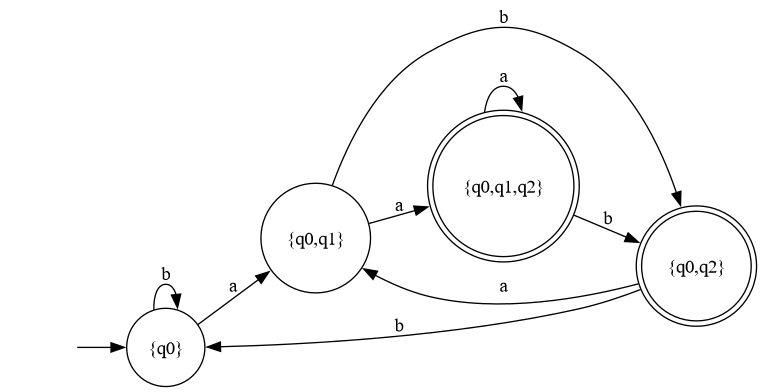

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# State diagram of cleaned up DFA accepting any string with "a" as its 
# second-to-last letter.
#
# ─────────────────────────────────────────────────────────────────────────────

fig_num_7 = "7"
title_7 = "Reduced NFA to DFA State Diagram (Reachable States Only)"
alt_text_7 = (
    "A reduced Deterministic Finite Automaton (DFA) derived from a subset construction, showing only the four reachable states. "
    "The states are {q0} (initial state), {q0, q1}, {q0, q2}, and {q0, q1, q2}. "
    "The accept states (double circles) are {q0, q2} and {q0, q1, q2}. "
    "Transitions are as follows: "
    "From {q0}: 'a' moves to {q0, q1}, 'b' loops back to {q0}. "
    "From {q0, q1}: 'a' moves to the accepting state {q0, q1, q2}, 'b' moves to the accepting state {q0, q2}. "
    "From {q0, q2} (Accept): 'a' moves to {q0, q1}, 'b' moves to {q0}. "
    "From {q0, q1, q2} (Accept): 'a' loops back to itself, 'b' moves to the accepting state {q0, q2}."
)

display_graph_with_caption(DFA_reduced, fig_num_7, title_7, alt_text_7)

This DFA recognizes the same language (all strings with $a$ as the next-to-last letter) as the NFA above, and so they are equivalent.

### Subsection 4.5.2 - Proof of the Equivalence of NFAs and DFAs

As mentioned above, DFAs are special cases of NFAs, so for any DFA there's obviously an equivalent NFA - the DFA itself.

Going the other way we'll want to formalize and generalize the construction we used above. This could be viewed as the first "real" proof in this book. Please don't be intimidated by it. There's nothing here that's more conceptually difficult than what we did in the example above - it just uses more general language.

---

**PROOF**

Let $N = (Q,\Sigma, \delta, S, F)$ be a NFA recognizing some language $A$. We construct a DFA $M = (Q', \Sigma, \delta', q_{0}', F')$ also recognizing $A$. Before going through the full construction, we'll first consider the easier case where $N$ has no $\lambda$-transitions.



1.   $Q' = P(Q)$. Every state of $M$ is a set of states of $N$. Recall that $P(Q)$ is the set of subsets of $Q$, knows as the *powerset* of $Q$.

2.   For $R \in Q'$ and $a \in \Sigma$, let $\delta'(R,a) = \{q \in Q | q \in \delta(r,a)$ for some $r \in R\}$. If $R$ is a state of $M$ it is also a set of states of $N$. When $M$ reads a symbol $a$ in state $R$, it shows where $a$ takes each state in $R$. Because each state may go to a set of states, we take the union of all these sets. A compact way of writing this is
<center>
  $\delta'(R,a) = \bigcup_{r \in R} \delta(r,a)$.
</center>

3.   $q_{0}' = S$. $M$ starts in the state corresponding to the start states of $N$.

4.   $F' = \{R \in Q | R$ contains an accepting state of $N\}$. The machine $M$ accepts if one of the possible states that $N$ could be in at this point is an accepting state.

For any NFA without $\lambda$-transitions (like the example from Subsection 4.5.1 above) the construction above will produce an equivalent DFA. For the case where an NFA has $\lambda$-transitions, we need to set up an extra bit of notation. For any state $R$ of $M$, we define $E(R)$ to be the collection of states that can be reached from members of $R$ by going only along $\lambda$ arrows, inculding the members of $R$ themselves. Formally, for $R \subseteq Q$ let

<center>
  $\displaystyle E(R) = \{q | q$ can be reached from $R$ by traveling along $0$ or more $\lambda$ arrows$\}$.
</center>

This operation is the *lambda_closure* function we defined in Section 4.4 above.

We then modify the transition functions of $M$ to be

<center>
  $\delta'(R,a) = \{q \in Q | q \in E(\delta(r,a))$  for some $r \in R\}$.
</center>

Finally, we modify the start state of $M$ to be all possible states that can be reached from the start states of $N$ along the $\lambda$-transitions. So, we change $q_{0}'$ to be $E(S)$.

With this modification, we have completed the construction of the DFA $M$ that simulates the NFA $N$, and is equivalent to it in that it recognizes the same language over $\Sigma$.

---

## Section 4.6 - References and Further Reading

* Introduction to Computer Theory (Second Edition) by Daniel I.A. Cohen

  *Chapter 6 - Transition Graphs*, *Chapter 7 - Kleene's Theorem*

* Automata Theory, Languages, and Computation (Third Edition) by Hopcroft, Motwani, and Ullman

  *Section 2.3 - Nondeterministic Finite Automata*

* Introduction to the Theory of Computation (Third Edition) by Michael Sipser
  
  *Section 1.2 - Nondeterminism*

## 4.7 Practice Problems

These problems assume you've got a working NFA class. If you've run all the code cells above, you should be good t go.

As in Chapter 3, there are no separate programming problems for this chapter, as programming is integrated with the practice problems below.

*Note* - For each of these exercises the alpbabet is $\Sigma = \{a,b\}$.

### Problem 4.7.1 - The "OR" Logic

Construct an NFA that accepts the set of all strings that start with 'a' OR end with 'b'. (Hint: Use multiple start states or a $\lambda$-transition to split into two separate logical branches).

### Problem 4.7.2 - Pattern Hunting

Construct an NFA that accepts any string containing the substring "bba". (Note: This is often much simpler in an NFA than a DFA because you can "guess" when the pattern starts).

### Problem 4.7.3 - The "N-th from End" Rule

Construct an NFA that accepts all strings where the third to last letter is an 'a'. (e.g., "bbabb" is accepted, "bbbbb" is rejected).

### Problem 4.7.4 - Length Modulo Union

Construct an NFA that accepts strings with a length divisible by 2 OR a length divisible by 3. (e.g., Length 2, 3, 4, 6, 8, 9... are accepted. Length 1, 5, 7... are rejected).

### Problem 4.7.5 - Zero or More (Star Operations)

Construct an NFA that recognizes the regular expression $\textbf{a}\textbf{b}^{*}\textbf{a}$. (This means: exactly one 'a', followed by zero or more 'b's, followed by exactly one 'a').